пишем ядро

1. Подгружаем yfinance → сырые цены (Open, High, Low, Close, Volume)
2. Рассчитываем признаки (RSI, lri, obv, atr)
3. Создаём целевую переменную (target) — "будет ли рост через N часов"
4. Делим данные (train/test)
5. Обучаем модели

In [7]:
!pip install hmmlearn

import pandas as pd
import numpy as np
import yfinance as yf
from hmmlearn import hmm
import xgboost as xgb

In [8]:
ticker = yf.Ticker("BTC-USD")
data = ticker.history(period="max")

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0




*   *open* - цена актива в начале
*   *high* - максимальная цена за весь период
*   *low*  - минималная цена за весь период
*   *close* - цена закрытия
*   *volume* - кол-во едииц актива, проданного за весь период, типо кол-во акций, кол-во криптомонет и тд
*   *dividends* - выплаты акционерам из прибыли компании, только для акций, значение появлятся в делнь выплат
*   *stock splits* - сплиты акций



In [9]:
dota = yf.download("BTC-USD", period="2y", interval='1h') # данные по биткоину за последние 2 года с интервалом в час
dota.head()
print(len(dota))

/tmp/ipykernel_847/530145028.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dota = yf.download("BTC-USD", period="2y", interval='1h') # данные по биткоину за последние 2 года с интервалом в час
[*********************100%***********************]  1 of 1 completed

17488


Возможно имеет смысл скачать больше данных, не забыть при этом обновить сплиттер

Выбранные метр ики для предсказания:
RSI,
LRI,
OBV,
ATR

нужно будет переписать так, чтобы было без pandas_ta

In [10]:
#import pandas as pd
#import numpy as np

def rsi(dat, period=14): # средний прирост на средний убыток +-
  delta = dat.diff()

  gain = (delta.where(delta > 0, 0))
  loss = (-delta.where(delta < 0, 0))

  avg_gain = gain.rolling(window=period).mean()
  avg_loss = loss.rolling(window=period).mean()

  rs = avg_gain / avg_loss
  rsi = 100 - (100 / (1 + rs))
  rsi[avg_loss == 0] = 100

  return rsi

def obv(close, vol): # определяем поддерживают ли тренд реальные деньги
  dir = np.sign(close.diff()).fillna(0)
  obv = (dir* vol).cumsum()
  obv.iloc[0] = vol.iloc[0]
  return obv

def atr(high, low, close, period=14):  # казывает волатильность
  tr1 = high - low
  tr2 = (high - close.shift()).abs()
  tr3 = (low - close.shift()).abs()

  tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

  atr = tr.rolling(window=period).mean()
  return atr

def feature_eng(dota):
  if isinstance(dota.columns, pd.MultiIndex):
        dota.columns = [col[0].lower() for col in dota.columns]
  else:
        dota.columns = [col.lower() for col in dota.columns]

  dota['rsi'] = rsi(dota['close']) # считаем на close так как это типо итог, закрытие периода
  # dota['lri_final'] = ta.linreg(dota['close'], length=14) обойдемся без линрега
  dota['obv'] = obv(dota['close'], dota['volume'])
  dota['atr'] = atr(dota['high'], dota['low'], dota['close'])
  dota = dota.dropna()
  return dota

dota2 = feature_eng(dota)
dota2.head()
my_feet = ['rsi', 'obv', 'atr']
#signes_cols = dota2[my_feet]  # выделили колонки для анализа hmm
#signes = signes_cols.values   # получили значения
print(len(dota2))


17475


target


In [11]:
price5 = dota2['close'].shift(-4) # предсказываем на 4 часа вперед
ratio = price5/dota2['close'] - 1
dota2['target'] = (ratio > 0.005).astype(int) # порог для покупки 0.003
print(dota2['target'])

Datetime
2024-05-13 05:00:00+00:00    1
2024-05-13 06:00:00+00:00    1
2024-05-13 07:00:00+00:00    1
2024-05-13 08:00:00+00:00    0
2024-05-13 09:00:00+00:00    0
                            ..
2026-05-12 12:00:00+00:00    0
2026-05-12 13:00:00+00:00    0
2026-05-12 14:00:00+00:00    0
2026-05-12 15:00:00+00:00    0
2026-05-12 16:00:00+00:00    0
Name: target, Length: 17475, dtype: int64


/tmp/ipykernel_847/3699134739.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dota2['target'] = (ratio > 0.005).astype(int) # порог для покупки 0.003


апроверяем баланс

In [12]:
counts = dota2['target'].value_counts()
percent = dota2['target'].value_counts(normalize=True) * 100

print("Количество по классам:\n", counts)
print("\nПроцентное соотношение:\n", percent)

Количество по классам:
 target
0    13453
1     4022
Name: count, dtype: int64

Процентное соотношение:
 target
0    76.984263
1    23.015737
Name: proportion, dtype: float64


Модели для решения первой задачи:


1.   XGBoost
2.   HMM
3.   LSTM
4.   Ансамбли Stacking



In [13]:
model1 = xgb.XGBClassifier(n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss')

In [14]:
from sklearn.preprocessing import MinMaxScaler
model2 = hmm.GaussianHMM(
    n_components=3,           # количество скрытых состояний
    covariance_type='full',   # тип ковариационной матрицы
    n_iter=1000,              # количество итераций EM-алгоритма
    random_state=42,          # для воспроизводимости
    verbose=True
)


сама модель:

In [16]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

In [17]:
class mineLSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_stack_layers): # input_size= number of feat, hidden_size, num_stack_layers
    super(mineLSTM, self).__init__() # для инициализации модели
    self.hidden_size = hidden_size
    self.num_stack_layers = num_stack_layers

    self.lstm = nn.LSTM(input_size, hidden_size, num_stack_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    batch_size = x.shape[0]
    h0 = torch.zeros(self.num_stack_layers, batch_size, self.hidden_size)
    c0 = torch.zeros(self.num_stack_layers, batch_size, self.hidden_size)

    out,_ = self.lstm(x, (h0, c0))
    out = self.fc(out[:, -1, :])

    return out

обучаем:

смотрим баланс классов

Ансамблевая модель:

In [18]:
from sklearn.linear_model import LogisticRegression

meta = LogisticRegression()


expend window split

In [19]:
def train_one_epoch(model_x):
  model_x.train(True)
  loss_now = 0.0

  for batch_index, batch in enumerate(test_loader):
    x_batch, y_batch = batch[0], batch[1]
    y_batch = y_batch.view(-1, 1).float()

    output = model_x(x_batch)
    loss = loss_fu(output, y_batch)
    loss_now += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


def validate_one_epoch(model_x): # тут мы смотрим какие показатели были у эпохи без смены градиентов
  model_x.train(False)
  loss_now = 0.0

  for batch_index, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0], batch[1]
    y_batch = y_batch.view(-1, 1).float()

    with torch.no_grad():
      output = model_x(x_batch)
      loss = loss_fu(output, y_batch)
      loss_now += loss

  avg_loss = loss_now/len(test_loader)

In [20]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10, test_size=168, gap=4, max_train_size=2160) # было 24 типо тестируем на сутках

for fold, (train_id, test_id) in enumerate(tscv.split(dota2)):
    train = dota2.iloc[train_id]  # iloc используем потому что splitter ориентируется на номера строк, iloc как раз
    test = dota2.iloc[test_id]    # позволяет именно по номеру обращаться к строке

    X_train = train.drop('target', axis=1)
    X_test = test.drop('target', axis=1)

    y_train = train['target']
    y_test = test['target']

    model1.fit(X_train, y_train)

    proba1 = model1.predict_proba(X_test)
    prediction1 = model1.predict(X_test)

    print('xgb')
    print(len(proba1))
    print(proba1.shape)

    scal = MinMaxScaler(feature_range=(-1,1))
    scal.fit(X_train[my_feet])

    signes_train = scal.transform(X_train[my_feet])
    signes_test = scal.transform(X_test[my_feet])

    model2.fit(signes_train)
    states0 = model2.predict_proba(signes_test)
    states = model2.predict(signes_test)

    anal = []
    current_targets = y_test.values
    for st in range(3):
        mask = (states == st)    # True там, где модель предсказала состояние 'st'
        avg_rsi = signes_test[mask, 0].mean()   # посчитали средний rsi, должен быть больше 60%
        groth = current_targets[mask].mean()   # частота роста
        anal.append([avg_rsi, groth])

    anal_summery = np.array(anal)

    print('\n hmm')
    print(states0)
    print(anal_summery)
    print(len(states))
    print(states)


    X_train_tuna = X_train.to_numpy()  # преобразовали в numpy массив
    X_test_tuna = X_test.to_numpy()
    y_train_tuna = y_train.to_numpy()  # преобразовали в numpy массив
    y_test_tuna = y_test.to_numpy()

    # скалировали данные
    X_train_tuna = scal.fit_transform(X_train_tuna)
    X_test_tuna = scal.transform(X_test_tuna)

    print('\n lstm')
    print(X_train_tuna.shape, X_test_tuna.shape, y_train_tuna.shape, y_test_tuna.shape)

    lookback = 24  # длина окна
    #X_train_tuna = X_train_tuna.reshape((-1, lookback, 8))
    #X_test_tuna = X_test_tuna.reshape((-1, lookback, 8))

    def y_create(x, y, lookback):
      y_my = []
      x_my = []
      for i in range(len(y)-lookback):
        x_my.append(x[i:i+lookback])
        y_my.append(y[i+lookback])
      return np.array(x_my), np.array(y_my)

    X_test_comby = np.vstack([X_train_tuna[-lookback:], X_test_tuna]) # подаем на вход для первого обучения последние тренировочные данные
    y_test_comby = np.concatenate([y_train_tuna[-lookback:], y_test_tuna])

    X_tr_tuna, y_tr_new  = y_create(X_train_tuna, y_train_tuna, lookback)
    X_te_tuna, y_te_new = y_create(X_test_comby, y_test_comby, lookback)

    print(X_tr_tuna.shape, X_te_tuna.shape, y_tr_new.shape, y_te_new.shape)  # тестовый y очень маленький нужно будет потом потыкаться в диапазоны, чтобы там была норм размерность

    X_tr_tuna = torch.tensor(X_tr_tuna).float()
    X_te_tuna = torch.tensor(X_te_tuna).float()
    y_tr_new = torch.tensor(y_tr_new).float()
    y_te_new = torch.tensor(y_te_new).float()

    print(X_tr_tuna.shape, X_te_tuna.shape, y_tr_new.shape, y_te_new.shape)

    train_dataset = TensorDataset(X_tr_tuna, y_tr_new)
    test_dataset = TensorDataset(X_te_tuna, y_te_new)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

    model3 = mineLSTM(8, 14, 3) # запустили модель input_size, hidden_size, num_layers
    loss_fu = nn.BCEWithLogitsLoss()
    learning_rate = 0.001
    optimizer = torch.optim.Adam(model3.parameters(), learning_rate)
    epochs=50

    for epoch in range(epochs):
      train_one_epoch(model3)
      validate_one_epoch(model3)

    predictions3 = []
    model3.eval()
    with torch.no_grad():
      prediction3 = model3(X_te_tuna)
      pred_np = torch.sigmoid(prediction3).detach().numpy().flatten() # сделали numpy массив
      predictions3.append(pred_np)
    print(pred_np)
    print(len(predictions3))


    print('\n meta')
    full_pred_ensembl = np.column_stack([proba1[:,1], states0[:, 1], pred_np])
    meta.fit(full_pred_ensembl, y_te_new)

    meta_pred = meta.predict(full_pred_ensembl)
    meta_proba = meta.predict_proba(full_pred_ensembl)[:, 1]

    print(meta_proba)
    print(full_pred_ensembl.shape)

print(len(X_test), len(X_train))

xgb
168
(168, 2)


         1   -4163.40753326             +nan
         2   -2452.95583666   +1710.45169660
         3   -2171.76338021    +281.19245645
         4   -2147.60829847     +24.15508174
         5   -2133.58812577     +14.02017270
         6   -2108.47446612     +25.11365965
         7   -2063.08485724     +45.38960888
         8   -2020.09113291     +42.99372434
         9   -1984.05005064     +36.04108226
        10   -1963.85162946     +20.19842119
        11   -1919.71977331     +44.13185614
        12   -1798.04341607    +121.67635725
        13   -1637.32810387    +160.71531219
        14   -1511.26908542    +126.05901846
        15   -1491.48237903     +19.78670639
        16   -1466.58339585     +24.89898318
        17   -1401.96738002     +64.61601583
        18   -1180.56995326    +221.39742676
        19    -705.47791760    +475.09203566
        20    -498.82614756    +206.65177004
        21    -498.82418115      +0.00196641
/tmp/ipykernel_847/2222694946.py:38: RuntimeWarning: Me


 hmm
[[2.06433121e-05 9.99979357e-01 1.11047889e-80]
 [4.78115402e-40 3.53042266e-38 1.00000000e+00]
 [2.44523133e-63 9.11385385e-60 1.00000000e+00]
 [2.56533135e-63 9.56817968e-60 1.00000000e+00]
 [1.92967748e-63 7.29524263e-60 1.00000000e+00]
 [1.65293375e-63 6.29370900e-60 1.00000000e+00]
 [5.49274448e-63 2.00134024e-59 1.00000000e+00]
 [7.89798973e-63 2.83935956e-59 1.00000000e+00]
 [2.43068318e-63 8.82606324e-60 1.00000000e+00]
 [9.98373095e-63 3.60238471e-59 1.00000000e+00]
 [9.48780763e-63 3.47694213e-59 1.00000000e+00]
 [1.47126207e-63 5.46388439e-60 1.00000000e+00]
 [5.38745019e-63 1.96150202e-59 1.00000000e+00]
 [5.45248252e-63 2.02328873e-59 1.00000000e+00]
 [3.39736486e-62 1.28132290e-58 1.00000000e+00]
 [1.86788879e-61 6.74487634e-58 1.00000000e+00]
 [1.66726756e-59 5.77448408e-56 1.00000000e+00]
 [5.93580953e-57 1.98292605e-53 1.00000000e+00]
 [3.54578308e-58 1.19303332e-54 1.00000000e+00]
 [1.74030043e-58 5.86057696e-55 1.00000000e+00]
 [4.16360005e-58 1.39494607e-54 1.

[0.250418   0.16960385 0.10422096 0.07013176 0.0586851  0.06090447
 0.07605702 0.11105866 0.16994515 0.25083998 0.34225693 0.42750672
 0.49274892 0.5294516  0.533977   0.4937187  0.39521495 0.34505242
 0.44915763 0.5683854  0.5983882  0.5689437  0.5151637  0.4526596
 0.403905   0.39020377 0.37657416 0.36483517 0.35282704 0.34101954
 0.33103457 0.32511806 0.32072327 0.3166389  0.3128451  0.30840352
 0.30376634 0.30081072 0.2908471  0.26620552 0.22281417 0.15919349
 0.09476643 0.05537351 0.03697994 0.02913669 0.02544232 0.02346657
 0.02218264 0.02127236 0.02062054 0.02013917 0.01987342 0.01979118
 0.02118395 0.01982727 0.01869971 0.01818188 0.01788729 0.01771031
 0.01760186 0.01752168 0.017521   0.01752506 0.01756321 0.01758889
 0.01758968 0.01755119 0.01752857 0.01749867 0.01747669 0.01745141
 0.01743419 0.01741902 0.01740777 0.0174028  0.01739703 0.01739031
 0.01737972 0.01737574 0.01737428 0.01738099 0.01738507 0.01739222
 0.01740216 0.01743095 0.01742724 0.01741644 0.01741969 0.01741

         1   -3694.68502969             +nan
         2   -2117.95575170   +1576.72927799
         3   -1710.12048060    +407.83527110
         4   -1149.12582276    +560.99465784
         5    -807.96276404    +341.16305872
         6    -786.60839802     +21.35436602
         7    -786.58925845      +0.01913957
         8    -786.58918264      +0.00007581
/tmp/ipykernel_847/2222694946.py:38: RuntimeWarning: Mean of empty slice.
  avg_rsi = signes_test[mask, 0].mean()   # посчитали средний rsi, должен быть больше 60%
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_847/2222694946.py:39: RuntimeWarning: Mean of empty slice.
  groth = current_targets[mask].mean()   # частота роста


...

         1   -2122.40343613             +nan
         2    -353.02517554   +1769.37826059
         3    -173.04940828    +179.97576727
         4    -159.24347076     +13.80593752
         5    -158.91605932      +0.32741144
         6    -158.89870932      +0.01735000
         7    -158.89716840      +0.00154092
/tmp/ipykernel_847/2222694946.py:38: RuntimeWarning: Mean of empty slice.
  avg_rsi = signes_test[mask, 0].mean()   # посчитали средний rsi, должен быть больше 60%
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_847/2222694946.py:39: RuntimeWarning: Mean of empty slice.
  groth = current_targets[mask].mean()   # частота роста



 hmm
[[1.85432451e-52 1.68842011e-35 1.00000000e+00]
 [1.50021962e-15 7.10270802e-13 1.00000000e+00]
 [1.51992204e-15 7.18222624e-13 1.00000000e+00]
 [1.50115714e-15 7.14599877e-13 1.00000000e+00]
 [1.54352844e-15 7.45896353e-13 1.00000000e+00]
 [1.69864555e-15 8.07126395e-13 1.00000000e+00]
 [1.71618600e-15 8.12225793e-13 1.00000000e+00]
 [1.81811112e-15 8.74292557e-13 1.00000000e+00]
 [1.77305491e-15 8.61243574e-13 1.00000000e+00]
 [1.57570502e-15 7.84175750e-13 1.00000000e+00]
 [1.56713606e-15 7.71629290e-13 1.00000000e+00]
 [1.49058897e-15 7.59335547e-13 1.00000000e+00]
 [9.78518606e-16 5.12436730e-13 1.00000000e+00]
 [9.62004562e-16 5.03206876e-13 1.00000000e+00]
 [9.41924657e-16 4.82632454e-13 1.00000000e+00]
 [1.00432478e-15 5.13758982e-13 1.00000000e+00]
 [9.83978617e-16 5.02594015e-13 1.00000000e+00]
 [6.36610170e-16 3.30192471e-13 1.00000000e+00]
 [1.00328699e-15 5.16294804e-13 1.00000000e+00]
 [1.00590861e-15 5.19980634e-13 1.00000000e+00]
 [1.22444190e-15 6.20821672e-13 1.

xgb
168
(168, 2)

 hmm
[[4.88695979e-41 7.34602484e-22 1.00000000e+00]
 [6.89461327e-01 3.10538673e-01 2.72256907e-11]
 [3.06570019e-01 6.93429981e-01 3.65705216e-17]
 [6.82860304e-01 3.17139696e-01 9.29582218e-17]
 [3.13055909e-01 6.86944091e-01 3.26610811e-17]
 [6.76486169e-01 3.23513831e-01 7.15596624e-17]
 [3.19322006e-01 6.80677994e-01 3.29488875e-17]
 [6.70335010e-01 3.29664990e-01 8.53487151e-17]
 [3.25367197e-01 6.74632803e-01 2.49132642e-17]
 [6.64395777e-01 3.35604223e-01 4.67265887e-17]
 [3.31204340e-01 6.68795660e-01 1.59449332e-17]
 [6.58659754e-01 3.41340246e-01 3.91001229e-17]
 [3.36840758e-01 6.63159242e-01 1.57567338e-17]
 [6.53120513e-01 3.46879487e-01 2.48282774e-17]
 [3.42284465e-01 6.57715535e-01 2.04162920e-17]
 [6.47767903e-01 3.52232097e-01 3.42801353e-17]
 [3.47544981e-01 6.52455019e-01 1.36318667e-17]
 [6.42598503e-01 3.57401497e-01 1.04442140e-17]
 [3.52625510e-01 6.47374490e-01 3.32747121e-18]
 [6.37606484e-01 3.62393516e-01 3.14818654e-18]
 [3.57530752e-01 

         1   -2567.99019713             +nan
         2   -1026.32618022   +1541.66401690
         3    -903.18363172    +123.14254851
         4    -779.06450069    +124.11913102
         5    -642.16262364    +136.90187705
         6    -495.23727168    +146.92535196
         7    -332.40611022    +162.83116146
         8    -240.30840404     +92.09770618
         9    -195.60753282     +44.70087122
        10    -180.67513045     +14.93240237
        11    -178.10602447      +2.56910598
        12    -177.94972845      +0.15629601
        13    -177.94184993      +0.00787853


[0.14227782 0.14226387 0.14225486 0.14224853 0.14224067 0.14223525
 0.1422331  0.14223848 0.14224556 0.14224942 0.14224836 0.14224313
 0.14223628 0.14223182 0.14223239 0.14223057 0.14222658 0.14222474
 0.14221989 0.14221181 0.14220347 0.14219497 0.14219414 0.1422049
 0.14220725 0.14220607 0.14220771 0.14221202 0.1422146  0.14221391
 0.14221534 0.14221455 0.14221713 0.14221962 0.1422258  0.14223036
 0.14223301 0.14223447 0.1422313  0.14222683 0.1422195  0.14221591
 0.14222012 0.14222711 0.14223024 0.1422307  0.1422343  0.14224766
 0.14227004 0.14228942 0.14229912 0.14229979 0.14230226 0.14230533
 0.14231798 0.14232631 0.14232577 0.14232443 0.14232896 0.14235292
 0.14235179 0.1423462  0.14234714 0.14234781 0.14234039 0.14233288
 0.14232631 0.14231823 0.1423128  0.14231482 0.14231712 0.14231792
 0.14231807 0.14232062 0.14231867 0.14231887 0.1423173  0.14231457
 0.14230846 0.1423086  0.14230525 0.14230122 0.14229704 0.14229482
 0.14228709 0.1422834  0.1422852  0.14228256 0.14228156 0.14227

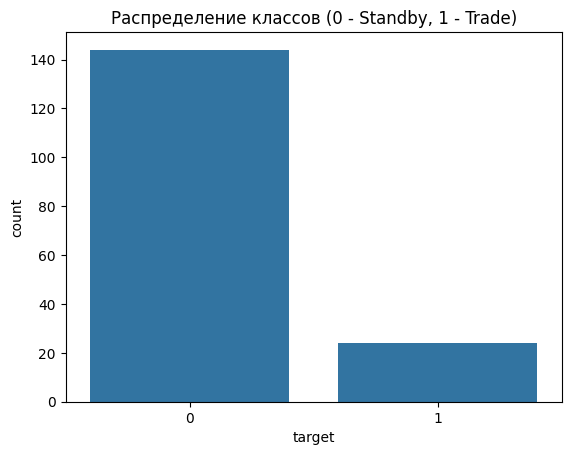

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y_test)
plt.title('Распределение классов (0 - Standby, 1 - Trade)')
plt.show()

Метрикипо моделям

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve
# дефолтные метрики xgb
cm = confusion_matrix(y_test, prediction1)
f1 = f1_score(y_test, prediction1)
precision = precision_score(y_test, prediction1)
recall = recall_score(y_test, prediction1)
prauc = average_precision_score(y_test, prediction1)
ll = log_loss(y_test, proba1)
print(cm, f1, precision, recall, prauc, ll)

"""# дефолтные метрики hmm ??? y_test, states
auc = roc_auc_score(y_test, states)  # вероятность что угадает класс, сортировка
prauc = average_precision_score(y_test, states)  # вероятность, что угадает редкий класс

ll = log_loss(y_test, states0)
print(cm, f1, precision, recall, ll)
"""
print('lstm\n')
# дефолтные метрики lstm
ll = log_loss(y_te_new, pred_np)
curve = calibration_curve(y_te_new, pred_np)
print(ll, curve)
print('mets\n')
# дефолтные метрики meta
cm = confusion_matrix(y_te_new, meta_pred)
f1 = f1_score(y_te_new, meta_pred)
precision = precision_score(y_te_new, meta_pred)
recall = recall_score(y_te_new, meta_pred)
print(cm, f1, precision, recall)


[[127  17]
 [ 19   5]] 0.21739130434782608 0.22727272727272727 0.20833333333333334 0.16044372294372294 0.5198468795085459
lstm

0.41011998824927026 (array([0.14285714]), array([0.14225808]))
mets

[[144   0]
 [ 24   0]] 0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Формула Келли чтобы понять сколько нужно купить


In [ ]:
def Kelly(proba, risk_reward, koef=0.5): # типо подаем на вход вероятность роста цены, отношение прибыль/убыток, коефициент сглаживания
  k = (proba - (1-proba)/risk_reward) * koef
  if k<0:
    return 0
  return k


In [ ]:
full_pred = np.column_stack([full_pred_ensembl, meta_proba]) # матрица с предсказаниями по массиву, 1 столбкц - 1 модель
print(full_pred.shape)
# full_pred_ensembl = np.column_stack([proba1[:,1], states, pred_np])

kelly0 =[]
kelly1 =[]
kelly2 =[]
kelly3 =[]

for pr1 in full_pred[:, 0]: # пробегаемся по первому столбцу, смотрим, что если у него вероятность больше 50 то покупаем
    # вункция для формулы келли и ml решение
    if pr1 > 0.5:
      kelly_vibes0 = Kelly(pr1, risk_reward=2)
      kelly0.append(kelly_vibes0)
    else:
      kelly0.append(0)

for pr3 in full_pred[:, 2]: # lstm
    # вункция для формулы келли и ml решение
    if pr3 > 0.5:
      kelly_vibes2 = Kelly(pr3, risk_reward=2)
      kelly2.append(kelly_vibes2)
    else:
      kelly2.append(0)

#masochka = ((full_pred[:, 1] == 1) & (full_pred[:, 2] > 0)) | ((full_pred[:, 1] < 0.4) & (full_pred[:, 2] > 0))
for pr2 in full_pred[:, 1]: # пробегаемся по столбцу с hmm с состояниями рынка
    # вункция для формулы келли и ml решение
    if pr3 > 0.5:
      kelly_vibes1 = Kelly(pr2, risk_reward=2)
      kelly1.append(kelly_vibes1)
    else:
      kelly1.append(0)

for pr4 in full_pred[:, 3]: # ensembl
    # вункция для формулы келли и ml решение
    if pr4 > 0.5:
      kelly_vibes3 = Kelly(pr4, risk_reward=2)
      kelly3.append(kelly_vibes3)
    else:
      kelly3.append(0)

print(len(full_pred))
print(len(kelly0), len(kelly1), len(kelly2), len(kelly3))


(24, 4)
24
24 24 24 24


Заполнение датасета с предсказаниями

In [ ]:
Agendatty = []

for i in range(len(full_pred)-4):
  date = X_test.index[i+4]
  inf = [
      {'model':'xgb', 'proba': full_pred[i, 0], 'kelly': kelly0[i]},
      {'model':'hmm', 'proba': full_pred[i, 1], 'kelly': kelly1[i]},
      {'model':'lstm', 'proba': full_pred[i, 2], 'kelly': kelly2[i]},
      {'model':'meta', 'proba': full_pred[i, 3], 'kelly': kelly3[i]}
  ]

  for j in inf:
    Agendatty.append({
        'date': date,
        'model name': j['model'],
        'probability': j['proba'],
        'how much': j['kelly']
    })

# af = df
asFack = pd.DataFrame(Agendatty)

asFack

,date,model name,probability,how much
0,2026-05-11 16:00:00+00:00,xgb,5.523375e-01,0.164253
1,2026-05-11 16:00:00+00:00,hmm,2.583955e-49,0.000000
2,2026-05-11 16:00:00+00:00,lstm,2.158349e-01,0.000000
3,2026-05-11 16:00:00+00:00,meta,2.600158e-01,0.000000
4,2026-05-11 17:00:00+00:00,xgb,4.336497e-01,0.000000
...,...,...,...,...
75,2026-05-12 10:00:00+00:00,meta,2.024328e-01,0.000000
76,2026-05-12 11:00:00+00:00,xgb,6.017943e-01,0.201346
77,2026-05-12 11:00:00+00:00,hmm,3.546412e-01,0.000000
78,2026-05-12 11:00:00+00:00,lstm,2.148868e-01,0.000000


сохраняем джейсончик для агента

In [ ]:
asFack.tail(1).to_json('ASFACK.json', orient='records')